In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "bot")
from config import ASSETS, CACHE_DIR

In [2]:
figi = ASSETS["SBERP"]

df_1m = pd.read_csv(CACHE_DIR / f"{figi}_1min.csv", parse_dates=["timestamp"])
df_5m = pd.read_csv(CACHE_DIR / f"{figi}_5min.csv", parse_dates=["timestamp"])

print(f"1min: {len(df_1m):>7,} bars  {df_1m.timestamp.min()} .. {df_1m.timestamp.max()}")
print(f"5min: {len(df_5m):>7,} bars  {df_5m.timestamp.min()} .. {df_5m.timestamp.max()}")
df_1m.head()

1min: 313,913 bars  2025-01-02 04:00:00+00:00 .. 2025-12-31 20:47:00+00:00
5min:  74,395 bars  2025-01-02 04:00:00+00:00 .. 2025-12-31 20:45:00+00:00


,timestamp,open,high,low,close,volume
0,2025-01-02 04:00:00+00:00,272.51,272.51,272.50,272.50,160
1,2025-01-02 04:02:00+00:00,275.25,275.25,275.25,275.25,10
2,2025-01-02 04:04:00+00:00,279.20,279.20,279.20,279.20,20
3,2025-01-02 04:05:00+00:00,279.21,279.22,278.76,278.76,130
4,2025-01-02 04:07:00+00:00,280.00,280.01,279.00,279.00,60


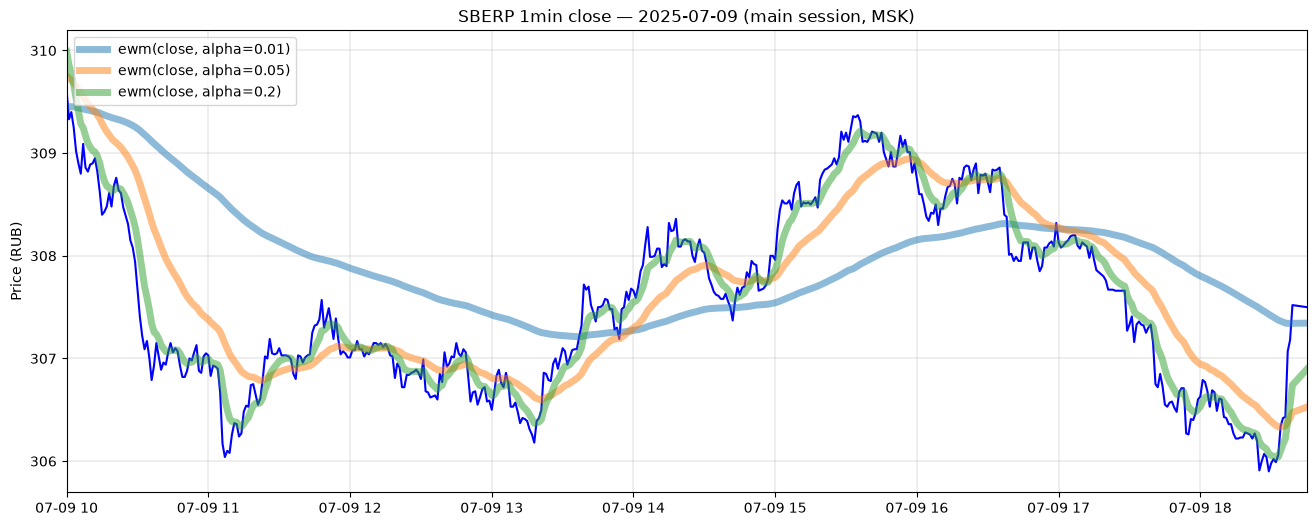

In [3]:
# One day of 1min candles + EWM trends of close, main MOEX session only, MSK time.
DAY = df_1m.timestamp.dt.date.values[150_000]  # pick any cached date here
ALPHAS = [0.01, 0.05, 0.2]

# MOEX time = Moscow (UTC+3). Drop the tz after converting so matplotlib
# shows MSK wall time on the axis instead of converting back to UTC.
ts_msk = df_1m.timestamp.dt.tz_convert("Europe/Moscow").dt.tz_localize(None)

# Main trading session: 10:00-18:45 MSK (excludes morning/evening sessions).
t = ts_msk.dt.time
in_main = (t >= pd.Timestamp("10:00").time()) & (t <= pd.Timestamp("18:45").time())

# EWM over the full series so the trend has warmup before the displayed day.
ewms = {a: df_1m["close"].ewm(alpha=a).mean() for a in ALPHAS}

day = df_1m[(ts_msk.dt.date == DAY) & in_main]
day_ts = ts_msk[day.index]
# up = day["close"] >= day["open"]
# colors = np.where(up, "seagreen", "tomato")

fig, ax = plt.subplots(figsize=(16, 6))

# ax.vlines(day_ts, day["low"], day["high"], color=colors, lw=0.5)
# body_lo = np.minimum(day["open"], day["close"])
# body_hi = np.maximum(day["open"], day["close"])
# ax.vlines(day_ts, body_lo, body_hi, color=colors, lw=2.5)

ax.plot(day_ts, day["close"], color="blue")
for a in ALPHAS:
    ax.plot(day_ts, ewms[a][day.index], lw=5, alpha=0.5, label=f"ewm(close, alpha={a})")

ax.set_title(f"SBERP 1min close — {DAY} (main session, MSK)")
ax.set_ylabel("Price (RUB)")
ax.legend(loc="upper left")
ax.grid(True, lw=0.3)
ax.margins(x=0)
plt.show()

In [6]:
# Strategy series over the full 1min history + 5min-model predictions mapped to 1min.
# Slow-ish (builds model features); run once, then re-plot different days below.
from backtest_mean_rev_z import predictions_for_1min, run_backtest

ALPHA = 0.05   # strategy alpha: EWM trend, EWM sigma (and EWM volume here)
Z_ENTRY = 1.0
INITIAL_CASH = 100_000.0

trend = df_1m["close"].ewm(alpha=ALPHA).mean()
sigma = df_1m["close"].ewm(alpha=ALPHA).std()
z = (df_1m["close"] - trend) / sigma
vol_ewm = df_1m["volume"].ewm(alpha=ALPHA).mean()

# Clamp to the cached range so nothing tries to hit the API.
preds, meta = predictions_for_1min(
    df_1m,
    pd.Timestamp("2025-01-04", tz="UTC"),
    pd.Timestamp("2025-12-30", tz="UTC"),
)
preds = pd.Series(preds, index=df_1m.index, name="pred")
print(f"Model test period starts: {meta['train_end_ts']} (earlier days are in-sample)")

# Actual strategy run (fills at bar open, decision on the previous bar).
bt = run_backtest(df_1m, alpha=ALPHA, z_entry=Z_ENTRY, predictions=preds.to_numpy(),
                  initial_cash=INITIAL_CASH)
trades = bt["trades"]
trades["ts_msk"] = pd.to_datetime(trades["timestamp"]).dt.tz_convert("Europe/Moscow").dt.tz_localize(None)
pnl = bt["equity"]["equity"] - INITIAL_CASH  # cumulative, aligned to df_1m rows
print(f"Trades: {len(trades)} fills ({(trades.qty > 0).sum()} buys, {(trades.qty < 0).sum()} sells), "
      f"final PnL: {pnl.iloc[-1]:.2f} RUB")

Using model: lgbm_20260703_133251.txt
  SBERP 5min: 73554 bars
  SBERP 15min: 26088 bars
  SBERP 30min: 13159 bars
  SBERP 1h: 6817 bars
  TMOS 5min: 39594 bars
  TMOS 15min: 14098 bars
  TMOS 30min: 7144 bars
  TMOS 1h: 3739 bars
  PLZL 5min: 72559 bars
  PLZL 15min: 25766 bars
  PLZL 30min: 12986 bars
  PLZL 1h: 6719 bars
  SIBN 5min: 73231 bars
  SIBN 15min: 26033 bars
  SIBN 30min: 13128 bars
  SIBN 1h: 6795 bars
  PHOR 5min: 67431 bars
  PHOR 15min: 25126 bars
  PHOR 30min: 12911 bars
  PHOR 1h: 6741 bars
Predictions: 73554 bars, mean=1.00000
Model test period starts: 2025-04-28 14:10:00+00:00 (earlier days are in-sample)
Trades: 12008 fills (6004 buys, 6004 sells), final PnL: -1609.35 RUB


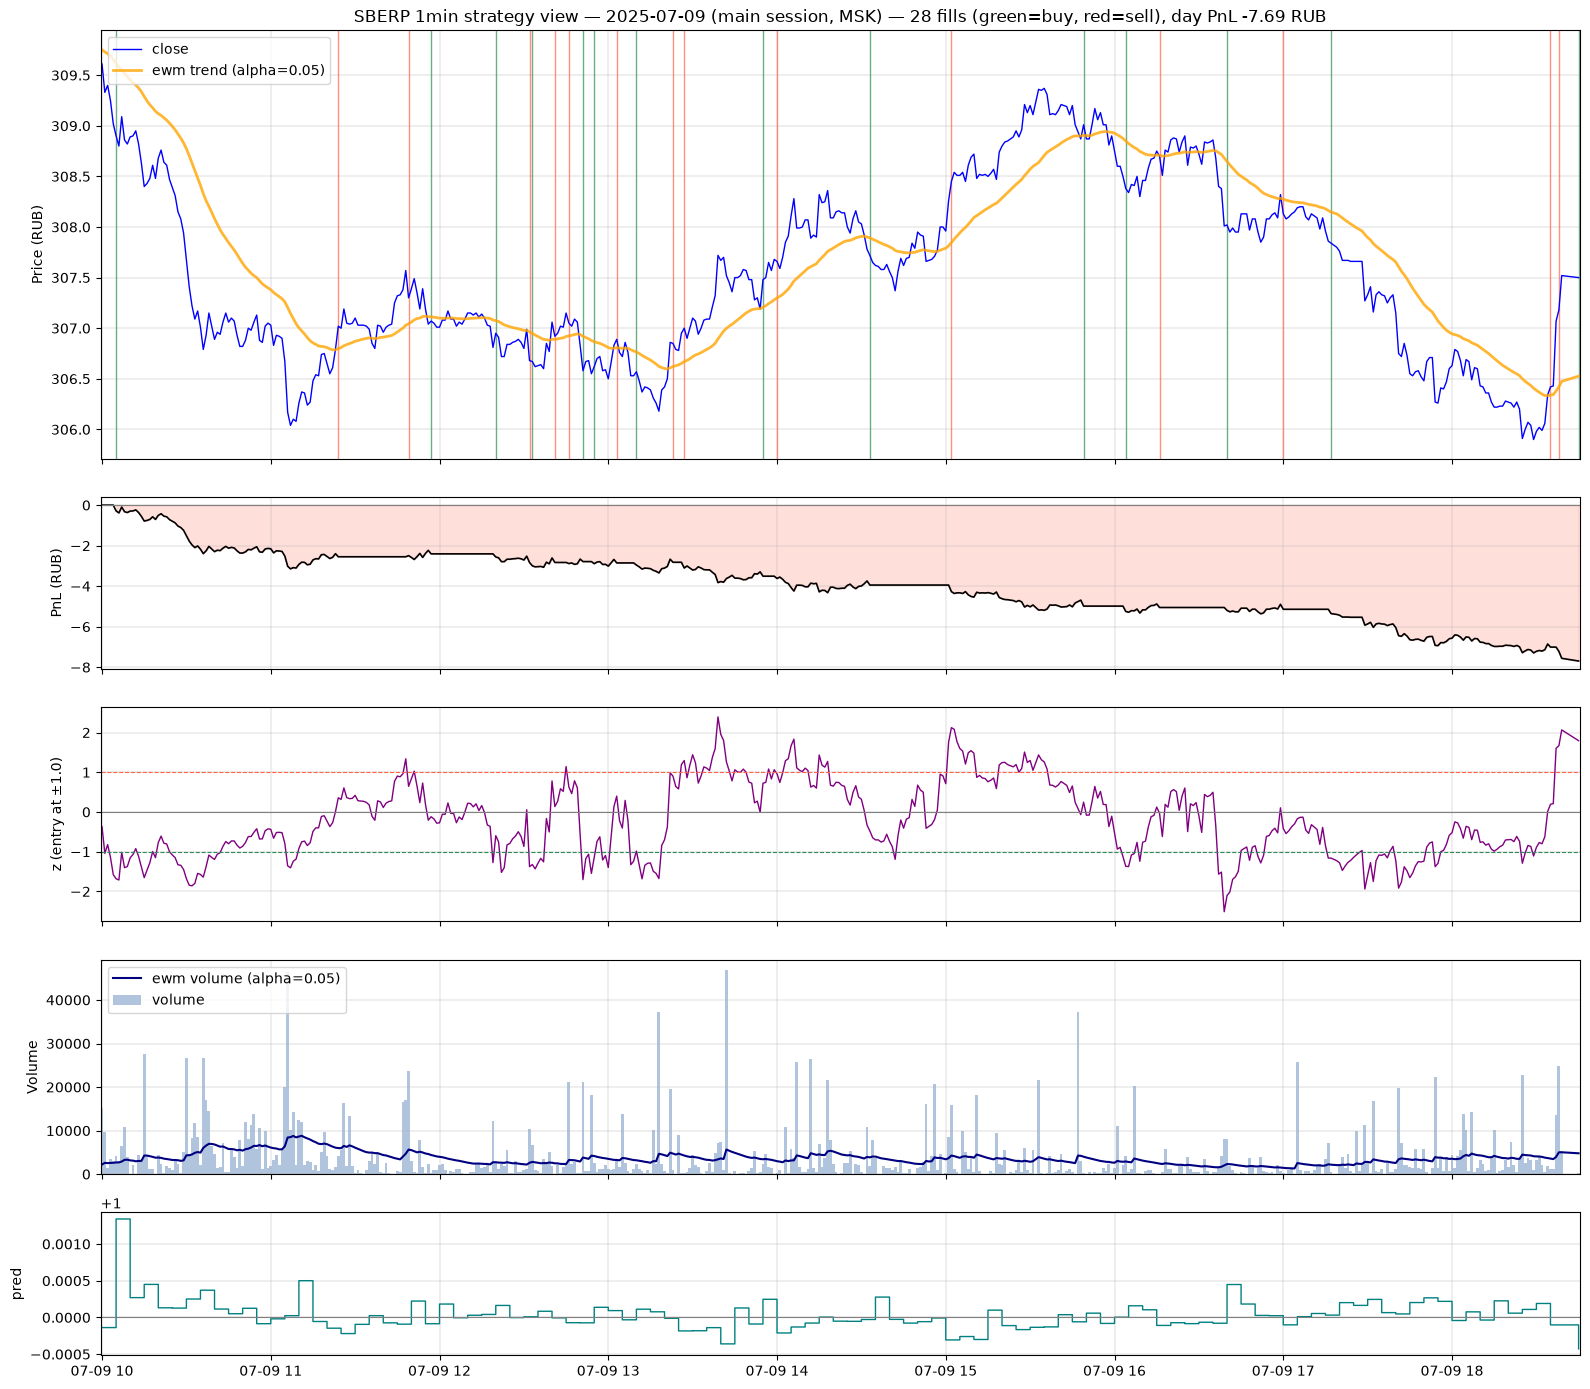

In [7]:
# One day, strategy view: price + trend + trades, PnL, z-score, volume + EWM volume, predictions.
day = df_1m[(ts_msk.dt.date == DAY) & in_main]
dts = ts_msk[day.index]
day_trades = trades[trades.ts_msk.dt.date == DAY]

fig, axes = plt.subplots(5, 1, figsize=(16, 14), sharex=True,
                         height_ratios=[3, 1.2, 1.5, 1.5, 1])

ax = axes[0]
for _, tr in day_trades.iterrows():
    ax.axvline(tr.ts_msk, color="seagreen" if tr.qty > 0 else "tomato", lw=1, alpha=0.7)
ax.plot(dts, day["close"], color="blue", lw=1, label="close")
ax.plot(dts, trend[day.index], color="orange", lw=2, alpha=0.8, label=f"ewm trend (alpha={ALPHA})")
ax.set_ylabel("Price (RUB)")
ax.legend(loc="upper left")

ax = axes[1]
# Day's PnL: cumulative equity re-based to the day's first bar.
day_pnl = pnl[day.index] - pnl[day.index[0]]
ax.plot(dts, day_pnl, color="black", lw=1.2)
ax.axhline(0, color="gray", lw=0.8)
ax.fill_between(dts, day_pnl, 0, where=day_pnl >= 0, color="seagreen", alpha=0.2)
ax.fill_between(dts, day_pnl, 0, where=day_pnl < 0, color="tomato", alpha=0.2)
ax.set_ylabel("PnL (RUB)")

ax = axes[2]
ax.plot(dts, z[day.index], color="purple", lw=1)
ax.axhline(0, color="gray", lw=0.8)
ax.axhline(Z_ENTRY, color="tomato", lw=0.8, ls="--")
ax.axhline(-Z_ENTRY, color="seagreen", lw=0.8, ls="--")
ax.set_ylabel(f"z (entry at ±{Z_ENTRY})")

ax = axes[3]
ax.bar(dts, day["volume"], width=1 / (24 * 60), color="lightsteelblue", label="volume")
ax.plot(dts, vol_ewm[day.index], color="navy", lw=1.5, label=f"ewm volume (alpha={ALPHA})")
ax.set_ylabel("Volume")
ax.legend(loc="upper left")

ax = axes[4]
# Predictions are per 5min block, so a step plot shows their true shape.
ax.step(dts, preds[day.index], where="post", color="teal", lw=1)
ax.axhline(1.0, color="gray", lw=0.8)
ax.set_ylabel("pred")

for ax in axes:
    ax.grid(True, lw=0.3)
    ax.margins(x=0)
axes[0].set_title(f"SBERP 1min strategy view — {DAY} (main session, MSK) — "
                  f"{len(day_trades)} fills (green=buy, red=sell), day PnL {day_pnl.iloc[-1]:+.2f} RUB")
fig.tight_layout()
plt.show()

In [ ]:
# Per-trade table + quick profitability analysis.
# Fills alternate entry/exit (position is always 0 or ±1), so pair them up.
# Indicator values are taken at the decision bar (fill bar - 1) — what the
# strategy actually saw; pred at the fill bar, as in the backtest.
fills = trades.reset_index(drop=True)
ent = fills.iloc[0::2].reset_index(drop=True)
ex = fills.iloc[1::2].reset_index(drop=True)
assert (ent.qty + ex.qty == 0).all(), "fills are not clean entry/exit pairs"

ts_index = pd.DatetimeIndex(df_1m["timestamp"])
ei = ts_index.get_indexer(pd.DatetimeIndex(ent["timestamp"]))   # entry fill bar
xi = ts_index.get_indexer(pd.DatetimeIndex(ex["timestamp"]))    # exit fill bar
dev = (df_1m["close"] / trend - 1) * 100  # % distance of close from EWM trend

trips = pd.DataFrame({
    "entry_msk": ent.ts_msk,
    "hour":      ent.ts_msk.dt.hour,                 # MSK entry hour
    "side":      np.sign(ent.qty).astype(int),       # +1 long, -1 short
    "bars_held": xi - ei,
    "gross_pnl": (ex.price - ent.price) * ent.qty,   # qty is signed
    "fees":      ent.fee + ex.fee,
    "z_in":      z.to_numpy()[ei - 1],
    "z_out":     z.to_numpy()[xi - 1],
    "dev_in":    dev.to_numpy()[ei - 1],
    "dev_out":   dev.to_numpy()[xi - 1],
    "vol_ewm_in":  vol_ewm.to_numpy()[ei - 1],
    "vol_ewm_out": vol_ewm.to_numpy()[xi - 1],
    "pred_in":   preds.to_numpy()[ei],
    "pred_out":  preds.to_numpy()[xi],
    "sigma_in":  sigma.to_numpy()[ei - 1],           # RUB volatility at entry
    "oos":       pd.DatetimeIndex(ent["timestamp"]) > pd.Timestamp(meta["train_end_ts"]),
})
trips["net_pnl"] = trips.gross_pnl - trips.fees
trips["abs_z_in"] = trips.z_in.abs()

print(f"{len(trips)} round trips | gross {trips.gross_pnl.sum():+.1f} RUB, "
      f"net {trips.net_pnl.sum():+.1f} RUB, fees {trips.fees.sum():.1f} RUB")
print(f"per trade: gross {trips.gross_pnl.mean():+.4f}, net {trips.net_pnl.mean():+.4f}, "
      f"fees {trips.fees.mean():.4f} RUB")
print(f"win rate: {(trips.gross_pnl > 0).mean():.1%} gross, {(trips.net_pnl > 0).mean():.1%} net")

print("\n=== correlation with PnL ===")
num_cols = ["side", "bars_held", "abs_z_in", "z_out", "dev_in", "dev_out",
            "vol_ewm_in", "vol_ewm_out", "pred_in", "pred_out", "sigma_in", "hour", "fees"]
print(trips[num_cols + ["gross_pnl", "net_pnl"]].corr()[["gross_pnl", "net_pnl"]]
      .drop(index=["gross_pnl", "net_pnl"]).round(3))

def by(label, key):
    g = trips.groupby(key, observed=True)
    out = pd.DataFrame({
        "n": g.size(),
        "gross_mean": g.gross_pnl.mean(),
        "net_mean": g.net_pnl.mean(),
        "net_sum": g.net_pnl.sum(),
        "win_gross": g.gross_pnl.apply(lambda s: (s > 0).mean()),
    })
    print(f"\n=== by {label} ===\n{out.round(3)}")

by("side", trips.side)
by("in/out of sample", trips.oos.map({False: "train period", True: "test period"}))
by("hour (MSK)", trips.hour)
by("|z| at entry", pd.qcut(trips.abs_z_in, 4, duplicates="drop"))
by("bars held", pd.qcut(trips.bars_held, 4, duplicates="drop"))
by("pred at entry", pd.qcut(trips.pred_in, 4, duplicates="drop"))
by("sigma at entry", pd.qcut(trips.sigma_in, 4, duplicates="drop"))

trips.head()